# 📘Домашнє завдання №8

**Лекція 16. Візуалізація за допомогою Matplotlib та Seaborn**

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW8

Завантажте Titanic Dataset і побудуйте для вибраних змінних наступні графіки:

1. **Числові змінні** (`age`, `fare`)
  * **Histogram** — розподіл
  * **Box Plot** — виявлення викидів
  * **KDE Plot** — гладкий розподіл
  * **Violin Plot** — порівняння розподілу по класу чи статі
2. **Залежності між змінними**
  * **Scatter Plot** — `age` vs `fare` (кольором або розміром `survived`)
  * **Bubble Chart** — додати розмір точки по `sibsp` або `parch`
3. **Категоріальні змінні**
  * **Bar Chart** — кількість пасажирів за класами та статтю
  * **Pie Chart** — частка виживших по класах
  * **Lollipop Chart** — середній `fare` по класах
4. **Кореляція та взаємозв’язки**
  * **Heatmap** — кореляція числових змінних (`age`, `fare`, `sibsp`, `parch`)

In [1]:
# Download data (to cover the case when the data aren't accessible)

import shutil
import sqlite3
import pandas as pd
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Input data
ds_name = "titanic"
db_file_name = "store_hw8.db"
git_project_url = "https://github.com/BogdanPinchuk/DataScience-PBY_HW8.git"
main_file_name = "Bohdan_Pinchuk_DS_HW8.ipynb"

# Solution
# global ds_data

# Note: to handle error: "SSL: CERTIFICATE_VERIFY_FAILED" or no connection to the server
try:
    # for testing
    # raise Exception
    ds_data = sns.load_dataset(ds_name)

    # Use only one time to initialize/update data (at first time)
    # conn = sqlite3.connect(db_file_name)
    # ds_data.to_sql(ds_name, conn, if_exists="replace", index=False)
    # conn.close()
except Exception:
    file_path = Path(db_file_name)

    if not file_path.exists():
        # upload all files
        current_path = !pwd
        current_path = current_path[0]
        parent_path = !dirname "$current_path"
        parent_path = parent_path[0]
        temp_path = f"{parent_path}/temp"

        # Clone data
        !rm -rf "$temp_path"
        !git clone "$git_project_url" "$temp_path"

        source = Path(temp_path)
        destination = Path(current_path)
        exclude = {main_file_name, ".git", ".idea"}

        for item in source.iterdir():
            if item.name in exclude:
                continue

            target = destination / item.name
            if item.is_dir():
                shutil.copytree(item, target, dirs_exist_ok=True)
            else:
                shutil.copy2(item, target)

        # Clean temp folder
        !rm -rf "$temp_path"

    conn = sqlite3.connect(db_file_name)
    ds_data = pd.read_sql(f"SELECT * FROM {ds_name}", conn)
    conn.close()

display(ds_data.head(2))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [2]:
# Числові змінні

# Input data
ages_col_name = "age"
fares_col_name = "fare"

# Solution
titanic = ds_data.copy()

# Extracting and cleaning data
ages_and_fares = titanic[[ages_col_name, fares_col_name]].dropna()
ages_and_fares[ages_col_name] = ages_and_fares[ages_col_name].round().astype(int)
ages_and_fares[fares_col_name] = ages_and_fares[fares_col_name].round(2).astype(float)

# Extracting and cleaning data
ages = ages_and_fares[ages_col_name].values
fares = ages_and_fares[fares_col_name].values

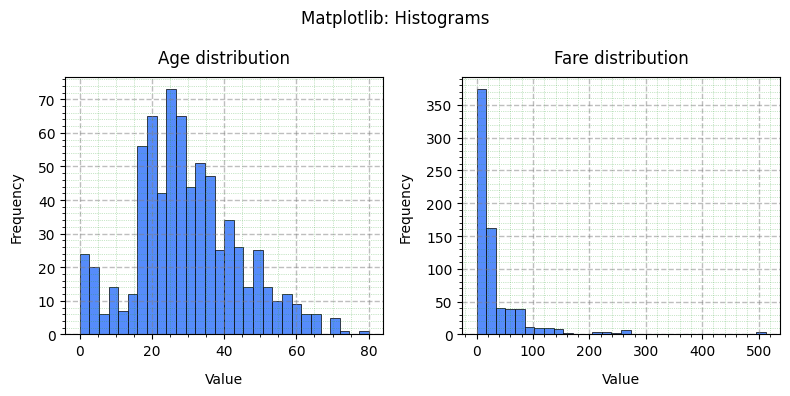

In [3]:
# Graphic results - Histograms - Matplotlib

import matplotlib.pyplot as plt

# Input data
n_bins = 30

# Solution
_, axes = plt.subplots(1, 2, figsize=(8, 4))

ax = axes[0]
ax.hist(ages, bins=n_bins, edgecolor="black", linewidth=0.5)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Age distribution", pad=10, loc='center', color='black')
ax.set_xlabel("Value", labelpad=10, loc='center', color='black')
ax.set_ylabel("Frequency", labelpad=10, loc='center', color='black')

ax = axes[1]
ax.hist(fares, bins=n_bins, edgecolor="black", linewidth=0.5)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Fare distribution", pad=10, loc='center', color='black')
ax.set_xlabel("Value", labelpad=10, loc='center', color='black')
ax.set_ylabel("Frequency", labelpad=10, loc='center', color='black')

plt.suptitle('Matplotlib: Histograms')

plt.tight_layout()
plt.show()

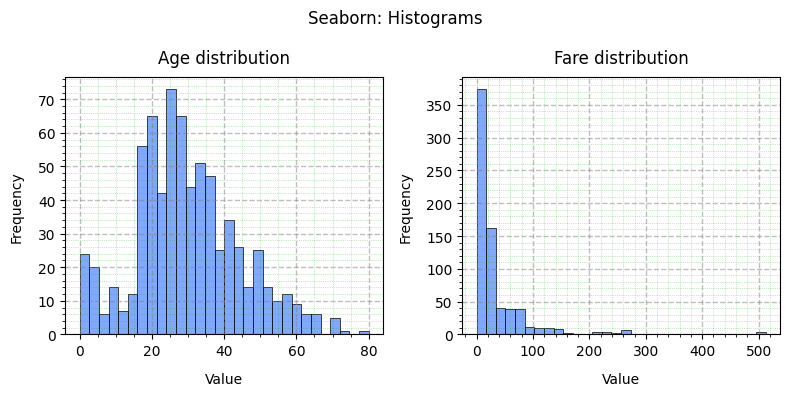

In [14]:
# Graphic results - Histograms - Seaborn

import seaborn as sns
import matplotlib.pyplot as plt

# Input data
n_bins = 30

# Solution
_, axes = plt.subplots(1, 2, figsize=(8, 4))

ax = axes[0]
sns.histplot(ages, ax=ax, bins=n_bins, edgecolor="black", linewidth=0.5)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Age distribution", pad=10, loc='center', color='black')
ax.set_xlabel("Value", labelpad=10, loc='center', color='black')
ax.set_ylabel("Frequency", labelpad=10, loc='center', color='black')

ax = axes[1]
sns.histplot(fares, ax=ax, bins=n_bins, edgecolor="black", linewidth=0.5)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Fare distribution", pad=10, loc='center', color='black')
ax.set_xlabel("Value", labelpad=10, loc='center', color='black')
ax.set_ylabel("Frequency", labelpad=10, loc='center', color='black')

plt.suptitle('Seaborn: Histograms')

plt.tight_layout()
plt.show()

In [5]:
# Graphic results - Histograms - Plotly

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# !pip install nbformat

# Input data
n_bins = 2 * 30

# Solution
fig = (make_subplots(1, 2, horizontal_spacing=0.125, subplot_titles=("Age distribution", "Fare distribution")).
       update_annotations(yshift=10))

row, col = 1, 1
fig.add_trace(
    go.Histogram(x=ages, name="age", nbinsx=n_bins, marker=dict(line=dict(color='black', width=0.5)),
                 showlegend=False), row=row, col=col)
fig.update_xaxes(title=dict(text="Value", standoff=2 * 10), row=row, col=col)
fig.update_yaxes(title=dict(text="Value", standoff=2 * 10), row=row, col=col)
fig.update_xaxes(showgrid=True, gridwidth=1.0, gridcolor='gray', griddash='dash', row=row, col=col)
fig.update_yaxes(showgrid=True, gridwidth=1.0, gridcolor='gray', griddash='dash', row=row, col=col)
# fig.update_xaxes(minor=dict(showgrid=True, gridcolor='green', gridwidth=0.5, griddash='dot'), row=row, col=col)
# fig.update_yaxes(minor=dict(showgrid=True, gridcolor='green', gridwidth=0.5, griddash='dot'), row=row, col=col)

row, col = 1, 2
fig.add_trace(go.Histogram(x=fares, name="fare", nbinsx=n_bins, marker=dict(line=dict(color='black', width=0.5)),
                           showlegend=False), row=row, col=col)
fig.update_xaxes(title=dict(text="Value", standoff=2 * 10), row=row, col=col)
fig.update_yaxes(title=dict(text="Value", standoff=2 * 10), row=row, col=col)
fig.update_xaxes(showgrid=True, gridwidth=1.0, gridcolor='gray', griddash='dash', row=row, col=col)
fig.update_yaxes(showgrid=True, gridwidth=1.0, gridcolor='gray', griddash='dash', row=row, col=col)
# fig.update_xaxes(minor=dict(showgrid=True, gridcolor='green', gridwidth=0.5, griddash='dot'), row=row, col=col)
# fig.update_yaxes(minor=dict(showgrid=True, gridcolor='green', gridwidth=0.5, griddash='dot'), row=row, col=col)

fig.update_layout(width=900, height=450, title_text='Plotly: Histograms', title_x=0.5, template="plotly_white")
fig.update_xaxes(showline=True, linewidth=1, linecolor='black', mirror=True)
fig.update_yaxes(showline=True, linewidth=1, linecolor='black', mirror=True)

fig.show()

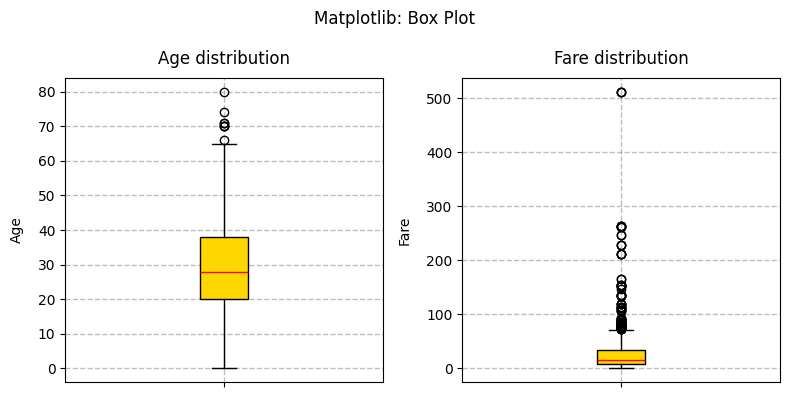

In [29]:
# Graphic results - Box Plot - Matplotlib

import matplotlib.pyplot as plt

# Input data

# Solution
_, axes = plt.subplots(1, 2, figsize=(8, 4))

ax = axes[0]
ax.boxplot(ages, tick_labels=[''], patch_artist=True,
           boxprops=dict(facecolor='gold', color='black', linewidth=1),
           medianprops=dict(color='red', linewidth=1))
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Age distribution", pad=10, loc='center', color='black')
ax.set_ylabel("Age", labelpad=10, loc='center', color='black')

ax = axes[1]
ax.boxplot(fares, tick_labels=[''], patch_artist=True,
           boxprops=dict(facecolor='gold', color='black', linewidth=1),
           medianprops=dict(color='red', linewidth=1))
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Fare distribution", pad=10, loc='center', color='black')
ax.set_ylabel("Fare", labelpad=10, loc='center', color='black')

plt.suptitle('Matplotlib: Box Plot')

plt.tight_layout()
plt.show()

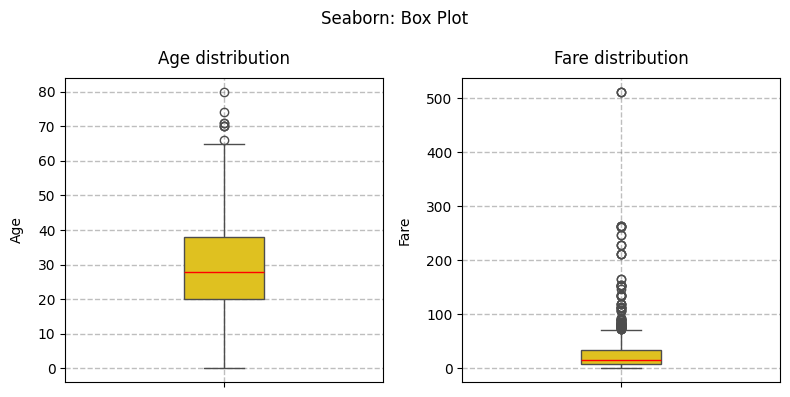

In [33]:
# Graphic results - Histograms - Seaborn

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
_, axes = plt.subplots(1, 2, figsize=(8, 4))

ax = axes[0]
sns.boxplot(ages, ax=ax,
            width=0.25, color='gold',
            medianprops={'color': 'red', 'linewidth': 1.0})
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Age distribution", pad=10, loc='center', color='black')
ax.set_ylabel("Age", labelpad=10, loc='center', color='black')

ax = axes[1]
sns.boxplot(fares, ax=ax,
            width=0.25, color='gold',
            medianprops={'color': 'red', 'linewidth': 1.0})
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Fare distribution", pad=10, loc='center', color='black')
ax.set_ylabel("Fare", labelpad=10, loc='center', color='black')

plt.suptitle('Seaborn: Box Plot')

plt.tight_layout()
plt.show()